In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [2]:
#--- Random Seeding + Device Checking ---
torch.manual_seed(8)
np.random.seed(8)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
#--- Creating a custom dataset class ---
class SharkFluorescenceDataset(Dataset):
    def __init__(self, csv_path, augment=False, mean=None, std=None):
        # Load CSV
        self.data = pd.read_csv(csv_path)
        
        # Extract species names (labels) from first column
        self.species = self.data.iloc[:, 0].values
        
        # Extract fluorescence values (all columns except first)
        # Shape: (num_samples, num_time_steps)
        self.fluorescence = self.data.iloc[:, 1:].values.astype(np.float32)

        # Normalization
        if mean is None or std is None:
            # Calculate mean and std from this data (for training set)
            self.mean = self.fluorescence.mean()
            self.std = self.fluorescence.std()
        else:
            # Use provided mean and std (for val/test sets)
            self.mean = mean
            self.std = std
        
        # Apply normalization: (x - mean) / std
        self.fluorescence = (self.fluorescence - self.mean) / self.std
        
        # Encode species names to numeric labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.species)
        
        self.num_classes = len(self.label_encoder.classes_)
        self.augment = augment
        
        print(f"Dataset loaded: {len(self.labels)} samples")
        print(f"Number of species: {self.num_classes}")
        print(f"Time series length: {self.fluorescence.shape[1]}")
        print(f"Augmentation: {'Enabled' if augment else 'Disabled'}")
        print(f"Data normalized with mean={self.mean:.6f}, std={self.std:.6f}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Get fluorescence values and add channel dimension
        # Shape: (1, num_time_steps) - 1D conv expects (channels, length)
        x = torch.FloatTensor(self.fluorescence[idx]).unsqueeze(0)

        # Apply augmentation if enabled
        if self.augment:
            # Small random noise
            noise = torch.randn_like(x) * 0.01
            x = x + noise
            # Random scaling
            scale = 1 + torch.FloatTensor([np.random.uniform(-0.05, 0.05)])
            x = x * scale
            # Random shift along time axis (small horizontal shift)
            shift = np.random.randint(-5, 6)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=1)
        
        # Get label
        y = torch.LongTensor([self.labels[idx]])[0]
        
        return x, y

In [4]:
# --- Residual Block Definition ---
class ResidualBlock1D(nn.Module):
    """
    1D Residual Block with two convolutional layers and a skip connection.
    This allows the network to learn residual functions, making training deeper networks easier.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super(ResidualBlock1D, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=stride, 
            padding=kernel_size//2,  # Same padding to maintain dimensions
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)  # Normalize activations
        
        # Second convolutional layer
        self.conv2 = nn.Conv1d(
            out_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=1, 
            padding=kernel_size//2,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # ReLU activation function
        self.relu = nn.ReLU(inplace=True)
        
        # Downsample layer for skip connection if dimensions don't match
        self.downsample = downsample
    
    def forward(self, x):
        # Store input for skip connection
        identity = x
        
        # First conv -> batch norm -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # Second conv -> batch norm
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Apply downsample to identity if needed (to match dimensions)
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection (residual)
        out += identity
        
        # Final activation
        out = self.relu(out)
        
        return out

In [5]:
#--- ResNet1D Definition [with Dropout] ---
class ResNet1D(nn.Module):
    """
    1D ResNet for time-series classification.
    Architecture:
    - Initial conv layer
    - Multiple residual blocks organized in layers
    - Global average pooling
    - Fully connected layer for classification
    """
    def __init__(self, num_classes, input_channels=1, initial_filters=64, dropout=0.65):
        super(ResNet1D, self).__init__()
        
        # Initial convolutional layer
        self.conv1 = nn.Conv1d(
            input_channels, 
            initial_filters, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(initial_filters)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers (ResNet-18 style: 2 blocks per layer)
        self.layer1 = self._make_layer(initial_filters, initial_filters, blocks=2)
        self.layer2 = self._make_layer(initial_filters, initial_filters*2, blocks=2, stride=2)
        self.layer3 = self._make_layer(initial_filters*2, initial_filters*4, blocks=2, stride=2)
        self.layer4 = self._make_layer(initial_filters*4, initial_filters*8, blocks=2, stride=2)
        
        # Global average pooling - reduces time dimension to 1
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Dropout layer: prevents overfitting
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer for classification
        self.fc = nn.Linear(initial_filters*8, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        """
        Create a layer consisting of multiple residual blocks.
        """
        downsample = None
        
        # If dimensions change, we need a downsample layer for the skip connection
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        # First block (may downsample)
        layers.append(ResidualBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        
        # Remaining blocks (no downsampling)
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global pooling and flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Classification layer
        x = self.fc(x)
        
        return x

In [6]:
#--- Training Function ---
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        # Move data to device (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [7]:
#--- Evaluation Function ---
def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on a dataset.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # No gradient computation during evaluation
    with torch.no_grad():
        for inputs, labels in dataloader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    total = len(all_labels)
    epoch_loss = running_loss / total
    epoch_acc = 100 * accuracy_score(all_labels, all_predictions)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

In [8]:
#--- Dataset + Split (change when needed) ---
# dataset = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)

# # Split dataset: 70% train, 15% val, 15% test
# train_size = int(0.7 * len(dataset))
# val_size = int(0.15 * len(dataset))
# test_size = len(dataset) - train_size - val_size

# train_dataset, val_dataset, test_dataset = random_split(
#     dataset, 
#     [train_size, val_size, test_size],
#     generator=torch.Generator().manual_seed(8)
# )

# # Train with augmentation, validation without
# dataset_train = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=True)
# dataset_eval = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)

# # Create dataloaders
# batch_size = 16
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# print(f"\nTrain samples: {len(train_dataset)}")
# print(f"Validation samples: {len(val_dataset)}")
# print(f"Test samples: {len(test_dataset)}")

train_dataset = SharkFluorescenceDataset('../../data/shark_training_data.csv', augment=True)

# Get normalization parameters from training data
train_mean = train_dataset.mean
train_std = train_dataset.std

# Load validation dataset (no augmentation, use training normalization)
val_dataset = SharkFluorescenceDataset('../../data/shark_validation_data.csv', augment=False, mean=train_mean, std=train_std)

# Load test dataset (no augmentation, use training normalization)
test_dataset = SharkFluorescenceDataset('../../data/shark_test_data.csv', augment=False, mean=train_mean, std=train_std)

# Create dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaded from pre-split CSV files:")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Total samples: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

# Store the training dataset reference for later use
full_dataset = train_dataset

Dataset loaded: 385 samples
Number of species: 55
Time series length: 3475
Augmentation: Enabled
Data normalized with mean=0.010661, std=0.013137
Dataset loaded: 129 samples
Number of species: 55
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010661, std=0.013137
Dataset loaded: 129 samples
Number of species: 55
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010661, std=0.013137

Data loaded from pre-split CSV files:
Train samples: 385
Validation samples: 129
Test samples: 129
Total samples: 643


In [9]:
#--- Model, Loss, Optimizer, Scheduler ---
# model = ResNet1D(num_classes=dataset.num_classes).to(device)
model = ResNet1D(num_classes=train_dataset.num_classes).to(device)

# Loss function (Cross Entropy for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam with learning rate)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5, 
)

# Print model summary
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Model architecture:
ResNet1D(
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 

In [10]:
#--- Training loop ---
num_epochs = 100
best_val_acc = 0.0
train_losses = []
val_losses = []
train_accs = []
val_accs = []
patience = 15
epochs_no_improve = 0
min_val_loss = float('inf')

print("\nStarting training...")
for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate on validation set
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet1d_shark.pth')
        print(f"  -> New best model saved!")

    # Early stopping
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve == patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"No improvement for {patience} consecutive epochs")
        break

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"Total epochs trained: {len(train_losses)}")


Starting training...
Epoch [1/100] Train Loss: 3.8632, Train Acc: 8.31% | Val Loss: 3.7454, Val Acc: 5.43%
  -> New best model saved!
Epoch [2/100] Train Loss: 3.3554, Train Acc: 19.48% | Val Loss: 5.1327, Val Acc: 6.98%
  -> New best model saved!
Epoch [3/100] Train Loss: 3.1292, Train Acc: 20.78% | Val Loss: 3.7652, Val Acc: 12.40%
  -> New best model saved!
Epoch [4/100] Train Loss: 2.8130, Train Acc: 27.53% | Val Loss: 2.8616, Val Acc: 23.26%
  -> New best model saved!
Epoch [5/100] Train Loss: 2.7045, Train Acc: 30.13% | Val Loss: 3.2388, Val Acc: 14.73%
Epoch [6/100] Train Loss: 2.5182, Train Acc: 30.65% | Val Loss: 3.0710, Val Acc: 20.16%
Epoch [7/100] Train Loss: 2.3750, Train Acc: 30.13% | Val Loss: 3.3501, Val Acc: 10.08%
Epoch [8/100] Train Loss: 2.2475, Train Acc: 36.62% | Val Loss: 2.0712, Val Acc: 41.09%
  -> New best model saved!
Epoch [9/100] Train Loss: 2.2722, Train Acc: 35.58% | Val Loss: 4.1578, Val Acc: 8.53%
Epoch [10/100] Train Loss: 2.2428, Train Acc: 36.10% | 

In [11]:
#--- Evaluation on test set ---
model.load_state_dict(torch.load('best_resnet1d_shark.pth'))

# Evaluate on test set
test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"\nClassification Report:")

# Get unique labels that actually appear in test set
unique_labels = sorted(list(set(test_labels)))
# target_names_test = [dataset.label_encoder.classes_[i] for i in unique_labels]
target_names_test = [train_dataset.label_encoder.classes_[i] for i in unique_labels]
print(classification_report(
    test_labels, 
    test_predictions,
    labels=unique_labels,
    target_names=target_names_test
))


TEST SET RESULTS
Test Loss: 0.4331
Test Accuracy: 89.92%

Classification Report:
                            precision    recall  f1-score   support

      Arabian smooth-hound       0.00      0.00      0.00         1
  Atlantic Sharpnose shark       0.50      1.00      0.67         1
      Blackchin guitarfish       1.00      1.00      1.00         1
           Blacknose shark       1.00      1.00      1.00         2
 Blackspotted smooth-hound       1.00      1.00      1.00         1
       Blacktip reef shark       1.00      1.00      1.00         1
            Blacktip shark       1.00      1.00      1.00         6
                Blue shark       0.88      1.00      0.93         7
          Bonnethead shark       1.00      0.50      0.67         2
       Bowmouth guitarfish       0.50      1.00      0.67         1
  Brownbanded bamboo shark       1.00      1.00      1.00         2
                Bull shark       1.00      0.83      0.91         6
      Caribbean reef shark       

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

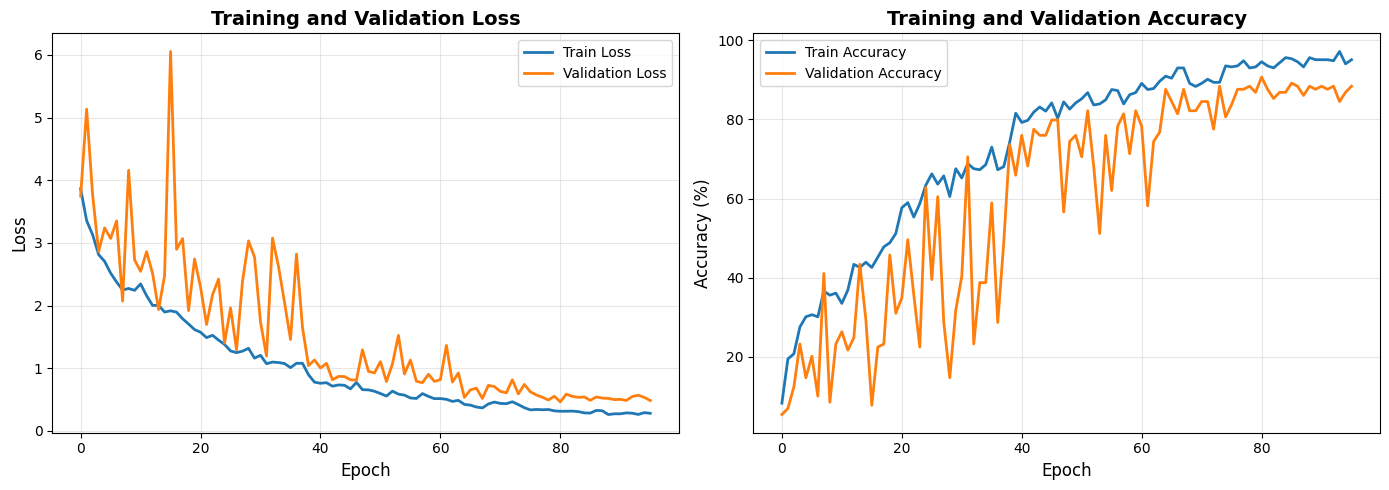


Training history plot saved as 'training_history.png'


In [12]:
#--- Plotting training history ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(val_accs, label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining history plot saved as 'training_history.png'")


TOP 5 BEST PERFORMING SPECIES
                  Species  F1-Score  Precision  Recall  Support
     Blackchin guitarfish       1.0        1.0     1.0        1
Blackspotted smooth-hound       1.0        1.0     1.0        1
          Blacknose shark       1.0        1.0     1.0        2
      Blacktip reef shark       1.0        1.0     1.0        1
           Blacktip shark       1.0        1.0     1.0        6

BOTTOM 5 WORST PERFORMING SPECIES
             Species  F1-Score  Precision  Recall  Support
 Bowmouth guitarfish  0.666667   0.500000     1.0        1
        Gulper shark  0.400000   0.333333     0.5        2
Arabian smooth-hound  0.000000   0.000000     0.0        1
   Great white shark  0.000000   0.000000     0.0        1
   Roughskin dogfish  0.000000   0.000000     0.0        1


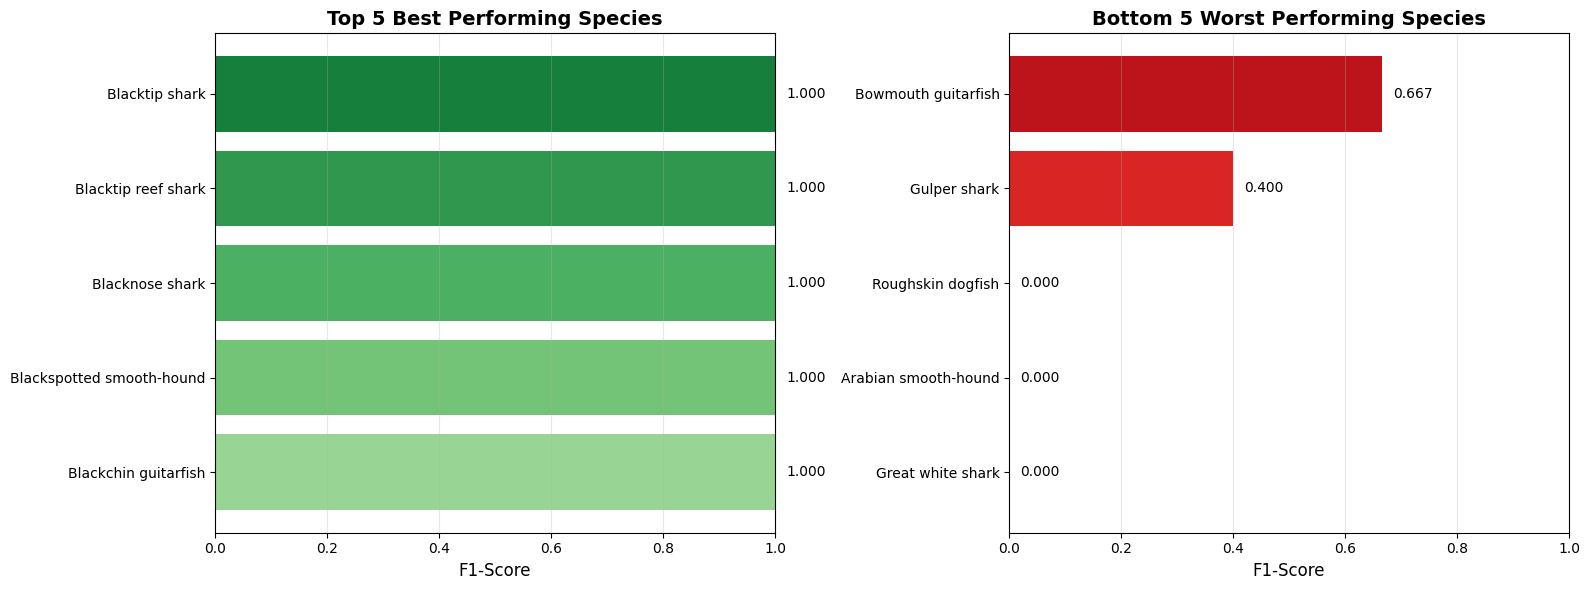


Species performance plot saved as 'species_performance.png'


In [13]:
#--- Top/Bottom Performing Species ---
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics (precision, recall, f1-score)
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, 
    test_predictions, 
    labels=unique_labels,
    zero_division=0
)

# Create dataframe with species performance
species_performance = pd.DataFrame({
    'Species': target_names_test,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Support': support
})

# Sort by F1-score
species_performance = species_performance.sort_values('F1-Score', ascending=False)

# Get top 5 and bottom 5
top_5 = species_performance.head(5)
bottom_5 = species_performance.tail(5)

print("\n" + "="*70)
print("TOP 5 BEST PERFORMING SPECIES")
print("="*70)
print(top_5.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 WORST PERFORMING SPECIES")
print("="*70)
print(bottom_5.to_string(index=False))

# Plot top 5 and bottom 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 5
top_5_sorted = top_5.sort_values('F1-Score', ascending=True)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_5_sorted)))
ax1.barh(range(len(top_5_sorted)), top_5_sorted['F1-Score'], color=colors_top)
ax1.set_yticks(range(len(top_5_sorted)))
ax1.set_yticklabels(top_5_sorted['Species'], fontsize=10)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('Top 5 Best Performing Species', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_5_sorted['F1-Score']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

# Bottom 5
bottom_5_sorted = bottom_5.sort_values('F1-Score', ascending=True)
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.8, len(bottom_5_sorted)))
ax2.barh(range(len(bottom_5_sorted)), bottom_5_sorted['F1-Score'], color=colors_bottom)
ax2.set_yticks(range(len(bottom_5_sorted)))
ax2.set_yticklabels(bottom_5_sorted['Species'], fontsize=10)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Bottom 5 Worst Performing Species', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(bottom_5_sorted['F1-Score']):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('species_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpecies performance plot saved as 'species_performance.png'")

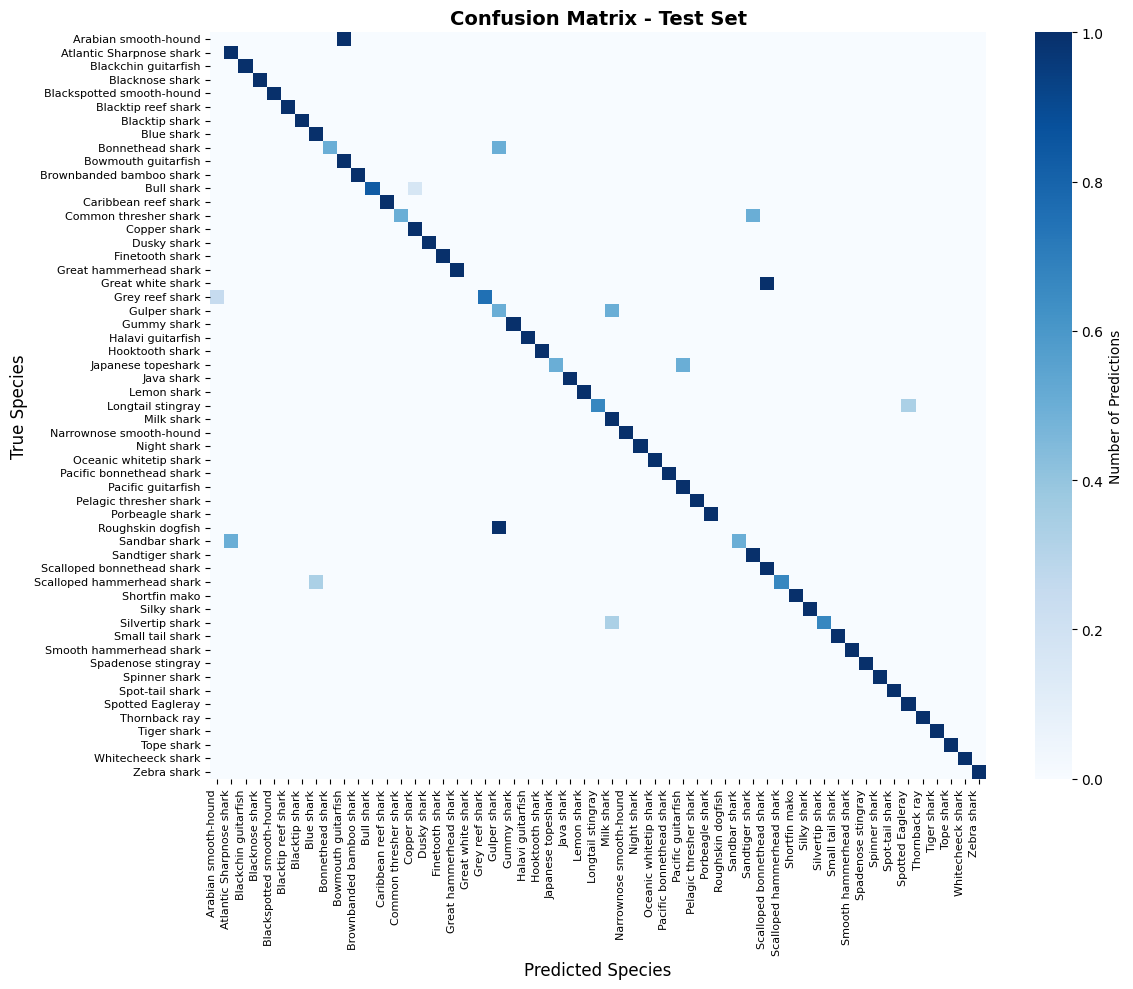

Confusion matrix saved as 'confusion_matrix.png'


In [16]:
#--- Confusion matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get confusion matrix for test set
cm = confusion_matrix(test_labels, test_predictions, normalize='true')

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=target_names_test, 
            yticklabels=target_names_test,
            cbar_kws={'label': 'Number of Predictions'})
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('True Species', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix.png'")